In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#Loading the dataset
url = "https://gist.githubusercontent.com/SINENSIA/b94e8ba33b7af499b7ddcaad312f7010/raw/c154fcbb099f0e542de8ea68b3821a0a2f7aeef2/tmdb_5000_movies.csv"
df = pd.read_csv(url)

#Selecting features and cleaning data
df = df[['budget', 'revenue', 'runtime', 'vote_average', 'popularity']].dropna()
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

#Target
df['is_superhit'] = (df['revenue'] > df['budget'] * 3).astype(int)

print(df.shape)

(3229, 6)


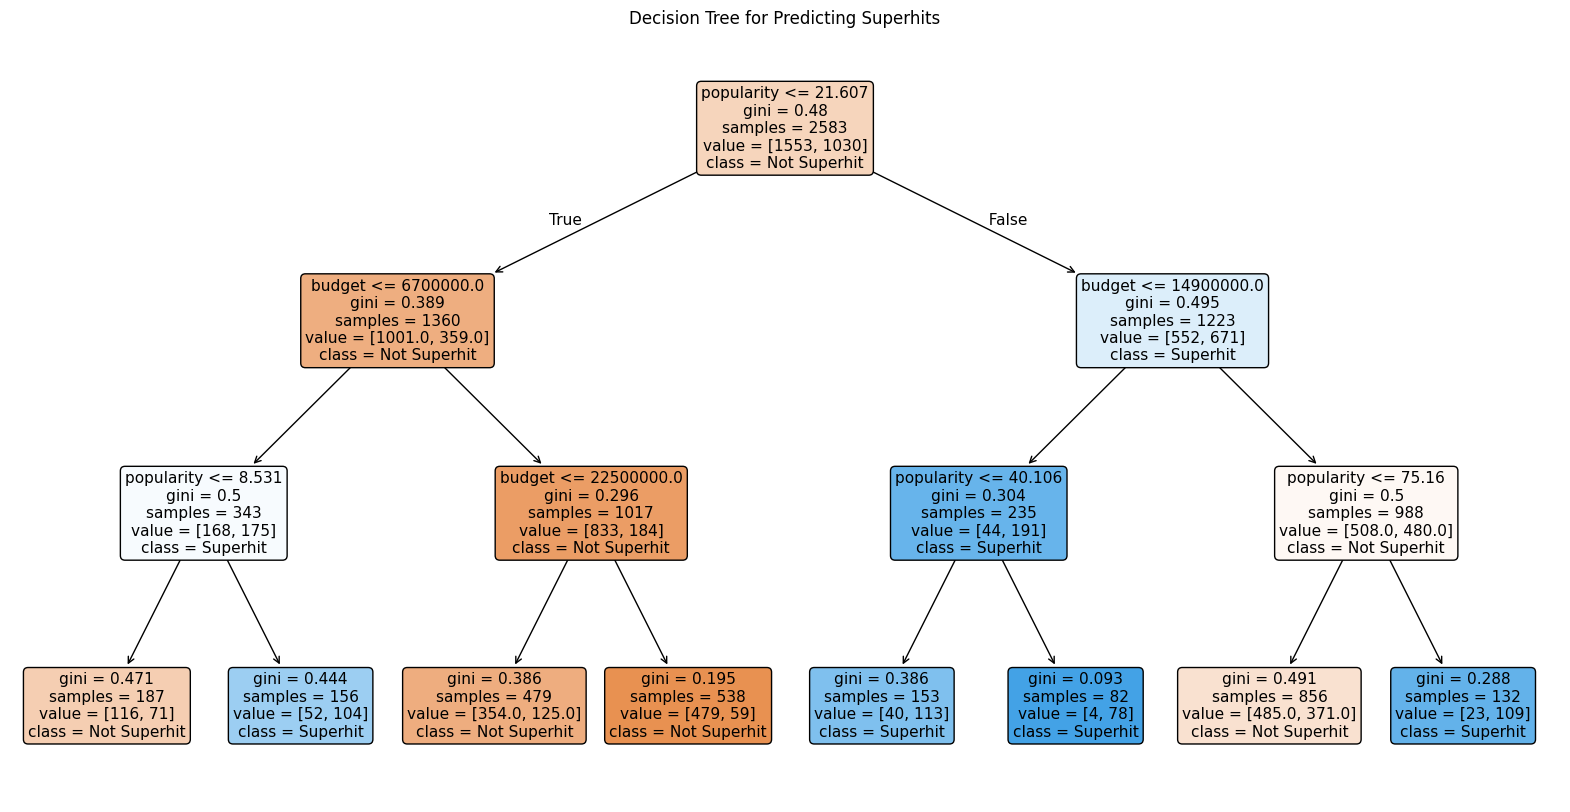

the most important feature at the root is: popularity


In [4]:
#preparing features and target
X_clf = df[['budget', 'runtime', 'vote_average', 'popularity']] #
y_clf = df['is_superhit']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
dt_classifier = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_classifier.fit(X_train, y_train)

#visualizing the tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=X_clf.columns, class_names=['Not Superhit', 'Superhit'], filled=True, rounded=True)
plt.title("Decision Tree for Predicting Superhits")
plt.show()

#root feature
root_feature_index = dt_classifier.tree_.feature[0]
print(f"the most important feature at the root is: {X_clf.columns[root_feature_index]}")

The feature at the very top of the tree (which is called the root) is the most important attribute for splitting the dataset for the first time, as it provides the highest information gain
Mathematically the Gini impurity measures uncertainty. The algorithm calculates the Gini impurity for all possible splits and chooses the one that results in the largest decrease in impurity. When a new movie lands in a final leaf the tree calculates the probability of it being a superhit by dividing the number of positive class training samples by the total number of training samples present in that specific leaf


In [7]:
#Given probabilities
probs = np.array([0.51, 0.51, 0.02]) #

#Majority Rule
tree_votes = (probs >= 0.5).astype(int)
hard_voting_prediction = 1 if np.sum(tree_votes) > (len(tree_votes) / 2) else 0

#Averaging Probabilities
average_probability = np.mean(probs)
soft_voting_prediction = 1 if average_probability >= 0.5 else 0

print(f"Individual Tree Votes: {tree_votes}")
print(f"Final Hard Voting Prediction: {hard_voting_prediction}")
print(f"Average Probability: {average_probability:.4f}")
print(f"Final Soft Voting Prediction: {soft_voting_prediction}")

Individual Tree Votes: [1 1 0]
Final Hard Voting Prediction: 1
Average Probability: 0.3467
Final Soft Voting Prediction: 0


Hard voting predicts a success (сlass 1) because two out of three trees voted positively. However, soft voting predicts a failure (сlass 0) because the average probability is roughly 0.346, falling below 0.5

For a high-stakes decision soft voting is significantly safer. Hard voting completely ignores the confidence of the predictions. Trees 1 and 2 were highly uncertain, while Tree 3 was absolutely convinced of a failure (0.02). Soft weighting accounts for this severe skepticism, preventing a financial risk.

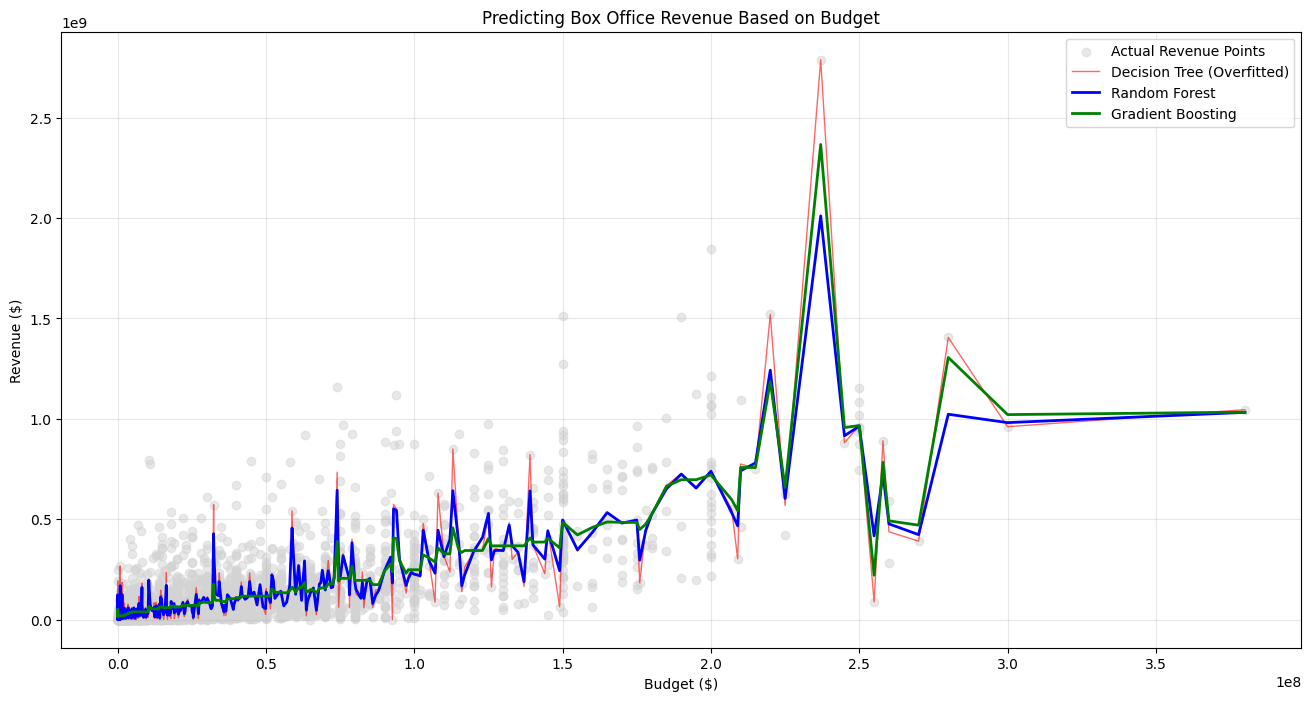

In [8]:
#Preparing regression data and sorting by budget
X_reg = df[['budget']].sort_values(by='budget')
y_reg = df.loc[X_reg.index, 'revenue']

dt_reg = DecisionTreeRegressor(random_state=42) #No depth limit!!!
rf_reg = RandomForestRegressor(n_estimators=300, max_features='sqrt', random_state=42)
gb_reg = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, random_state=42)

dt_reg.fit(X_reg, y_reg)
rf_reg.fit(X_reg, y_reg)
gb_reg.fit(X_reg, y_reg)

#Plotting the predictions
plt.figure(figsize=(16, 8))
plt.scatter(X_reg, y_reg, color='lightgray', alpha=0.5, label='Actual Revenue Points')

plt.plot(X_reg, dt_reg.predict(X_reg), color='red', alpha=0.6, linewidth=1, label='Decision Tree (Overfitted)')
plt.plot(X_reg, rf_reg.predict(X_reg), color='blue', linewidth=2, label='Random Forest')
plt.plot(X_reg, gb_reg.predict(X_reg), color='green', linewidth=2, label='Gradient Boosting')

plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.title('Predicting Box Office Revenue Based on Budget')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Decision Tree (red): the graph shows the red line sharply spiking up and down to touch specific outlier points. This is a perfect illustration of overfitting. It perfectly memorized the training data (the noise)  

Ensembles (blue and green): Random Forest and Gradient Boosting are not perfectly smooth curves (like a linear regression would be). They are still somewhat spiky because they are based on trees. However, because of averaging in Forest and sequential error correction in Boosting, their lines stay much lower than the extreme peaks of the red line, showing a more realistic trend

On the left side of the graph (budgets under 100 million), the gray dots are packed very tightly as revenues are predictable and rarely exceed 1 billion.   

However, on the right side (budgets from 150 million to 300 million), the spread of the box office revenues becomes larger. A movie with a 250 million budget can either flop or gross almost 3 billion (the highest point on the graph).  

It is hard for algorithms to minimize the MSE when for the exact same X values (a huge budget), the Y values (revenue) can differ by billions of dollars. This is exactly why at high budgets the ensemble lines (blue and green) start to fluctuate heavily (they are trying to find a compromise)